# 汽车保险产品发布的关键路径调度

## 执行摘要

发布个人汽车保险产品是一项跨职能的项目：精算师为风险定价，合规部门向州监管机构提交费率并等待批准，IT 配置保单管理系统，分销部门培训代理人。这些任务之间存在严格的先后关系，因此发布日期由贯穿整个计划的最长依赖链——**关键路径**——决定。

本 notebook 构建了一个包含十一项发布任务的节点式（Activity-on-Node）项目网络，并使用 **PROC OPTMODEL** 计算完整的**关键路径法（CPM）**进度计划。CPM 的正向与反向遍历是在先后关系图上的线性规划：正向遍历（从起点出发的最长路径）给出每项任务的最早开始与最早完成时间，反向最长路径遍历给出最晚开始与最晚完成时间以及**总时差**（进度余量）。下文的结果完全由本 notebook 中的代码生成——叙述中的每一个数字都是从执行输出中读回的。

**进度计划揭示了什么。** 在以 01JUN2026 为锚点的五天工作日历上，该项目跨越 **97 个工作日**，于 **13OCT2026** 完成。十一项任务中有九项位于关键路径上（启动 -> 市场调研 -> 损失数据汇总 -> 定价 -> 系统设计 -> 系统构建 -> UAT -> 代理人培训 -> 发布），且总时差为零。只有监管分支——**费率提交**与**批准**——存在余量：由于并行的系统构建分支是两条汇聚路径中较长的一条，因此这两项任务各自最多可推迟 **30 个工作日**而不影响发布。

## 构建方式

CPM 传统上是一个 SAS/OR 过程，但其核心计算是先后关系图上的一对最长路径问题，PROC OPTMODEL 可将其直接表示为小型线性规划：

- **正向遍历（最早时间）。** 在满足每条先后关系弧的约束 `ES[successor] >= ES[predecessor] + duration + lag` 的条件下，最小化最早开始变量。在最优解处，每个 `ES` 等于从项目起点出发的最长路径，即该任务能够开始的最早时间。
- **反向遍历（最晚时间 / 时差）。** 对每项任务，计算通往项目终点的最长剩余路径（`TAIL`）。最晚开始时间即为 `makespan - TAIL`，而**总时差**为 `late start - early start`。总时差为零的任务是关键任务。

网络、工期、先后关系滞后量以及每项任务的资源需求全部在代码中内联生成；没有任何外部输入。工作日日历日期通过 `INTNX('weekday', ...)` 推导，从而跳过周末。

## 数据

| 数据集 | 行数 | 关键变量 | 说明 |
|---------|------|---------------|-------------|
| `acts`  | 11 | `id`、`activity`、`dur`、`actuary`、`developer` | 活动主表：每项发布任务、其工作日工期，以及每日所需的精算师 / 开发人员人数 |
| `arcs`  | 12 | `pred`、`succ`、`lag` | 节点式网络的先后关系弧；`lag` 是以工作日计的完成到开始延迟（批准后的监管等待期） |

数值型活动 ID 作为网络的键，使先后关系图能够清晰地读入 OPTMODEL 的元组集合；可读的 `activity` 名称随后再合并回进度计划。

In [1]:
数据 acts;
   长度 activity $32;
   输入 id activity $ dur actuary developer;
   DATALINES;
1 启动           3 1 0
2 市场调研        8 2 0
3 损失数据汇总    10 3 0
4 定价           9 3 1
5 费率提交        4 1 0
6 批准           6 1 0
7 系统设计       12 1 2
8 系统构建       18 0 3
9 UAT           15 0 2
10 代理人培训    20 1 1
11 发布          2 1 1
;
运行;

数据 arcs;
   输入 pred succ lag;
   DATALINES;
1 2 0
2 3 0
3 4 0
4 5 0
4 7 0
5 6 0
6 10 5
7 8 0
8 9 0
9 10 0
9 11 0
10 11 0
;
运行;

/* 仅含数值的工期视图，供 OPTMODEL 使用 */
数据 acts_n; 设置 acts; 保留 id dur; 运行;


NOTE: DATA acts

NOTE: Processing inline DATALINES (11 lines)

NOTE: Read 11 rows from DATALINES.
NOTE: Wrote acts (11 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA arcs

NOTE: Processing inline DATALINES (12 lines)

NOTE: Read 12 rows from DATALINES.
NOTE: Wrote arcs (12 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA acts_n


NOTE: Read 11 rows from acts.
NOTE: Wrote acts_n (11 rows, 2 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


## 正向遍历——最早开始与完成时间

正向遍历是一个最长路径 LP。对每条弧施加约束 `ES[j] >= ES[i] + dur[i] + lag[i,j]`，迫使每项任务不早于其所有前驱完成（加上任何监管滞后）后才开始；最小化最早开始变量将每个变量驱动至其最长前驱路径。我们将求解得到的 `ES` 值直接从 OPTMODEL 变量写入 `fwd`。

In [2]:
proc optmodel;
   set NODES; num dur{NODES};
   read data acts_n into NODES=[id] dur=dur;

   set <num,num> ARCS; num lag{ARCS};
   read data arcs into ARCS=[pred succ] lag=lag;

   var ES{NODES} >= 0;
   con prec{<i,j> in ARCS}:
       ES[j] >= ES[i] + dur[i] + lag[i,j];
   min total_es = sum{k in NODES} ES[k];
   solve;

   create data fwd from [id]=NODES es=ES;
quit;


                        The OPTMODEL Procedure

                           Problem Summary
  Objective Sense               Minimization
  Objective Function            TOTAL_ES
  Objective Type                Linear

  Number of Variables           11
  Bounded Above                 0
  Bounded Below                 11
  Bounded Below and Above       0
  Free                          0
  Fixed                         0

  Number of Constraints         12

                          Solution Summary
  Solver                        LP
  Objective Function            TOTAL_ES
  Solution Status               Optimal
  Objective Value               401.0000000000




NOTE: PROC OPTMODEL 

NOTE: Using Python scipy version 1.16.3
NOTE: PROC OPTMODEL completed.


## 反向遍历——最晚时间与总时差

`TAIL[a]` 是从任务 `a` 到项目终点的最长路径，因此它必须覆盖任务自身的工期，并且对每个后继任务，覆盖滞后量加上该后继任务的 tail：`TAIL[i] >= dur[i] + lag[i,j] + TAIL[j]`。最小化 tail 可得到最紧的此类值。项目的 **makespan** 是最大的最早完成时间；每项任务的**最晚开始时间**为 `makespan - TAIL`，而**总时差**为 `late start - early start`。时差为零标记出关键路径。

In [3]:
proc optmodel;
   set NODES; num dur{NODES};
   read data acts_n into NODES=[id] dur=dur;

   set <num,num> ARCS; num lag{ARCS};
   read data arcs into ARCS=[pred succ] lag=lag;

   var TAIL{NODES} >= 0;
   con base{a in NODES}: TAIL[a] >= dur[a];
   con back{<i,j> in ARCS}:
       TAIL[i] >= dur[i] + lag[i,j] + TAIL[j];
   min total_tail = sum{k in NODES} TAIL[k];
   solve;

   create data bwd from [id]=NODES tail=TAIL;
quit;


                        The OPTMODEL Procedure

                           Problem Summary
  Objective Sense               Minimization
  Objective Function            TOTAL_TAIL
  Objective Type                Linear

  Number of Variables           11
  Bounded Above                 0
  Bounded Below                 11
  Bounded Below and Above       0
  Free                          0
  Fixed                         0

  Number of Constraints         23

                          Solution Summary
  Solver                        LP
  Objective Function            TOTAL_TAIL
  Solution Status               Optimal
  Objective Value               606.0000000000




NOTE: PROC OPTMODEL 

NOTE: Using Python scipy version 1.16.3
NOTE: PROC OPTMODEL completed.


## 组装进度计划与日历

我们将最早开始时间与 tail 合并回活动主表，推导出最晚开始 / 完成时间与总时差，并用 `INTNX('weekday', ...)` 将工作日偏移量映射为日历日期，使日期落在工作日上。当某项任务的总时差为零时，将其标记为**关键**。

In [4]:
%LET anchor = '01jun2026'd;

数据 sched0;
   合并 acts fwd bwd; 按照 id;
   ef = es + dur;            /* 最早完成 */
运行;

过程 均值 数据=sched0 NOPRINT;
   输出 out=mk(drop=_type_ _freq_) MAX(ef)=makespan;
运行;

数据 sched;
   如果 _n_=1 那么 设置 mk;
   设置 sched0;
   保留值 mspan;
   如果 _n_=1 那么 mspan = makespan;
   ls = mspan - tail;        /* 最晚开始 */
   lf = ls + dur;            /* 最晚完成 */
   tfloat = ls - es;         /* 总时差   */
   e_start  = intnx('weekday', &anchor, es,   'b');
   e_finish = intnx('weekday', &anchor, ef-1, 'b');
   l_start  = intnx('weekday', &anchor, ls,   'b');
   l_finish = intnx('weekday', &anchor, lf-1, 'b');
   critical = (round(tfloat,1e-6)=0);
   长度 cclass $12;
   如果 critical 那么 cclass='关键';
   否则 cclass='浮动';
   格式 e_start e_finish l_start l_finish date9.;
运行;

过程 排序 数据=sched out=sched_es; 按照 es id; 运行;


NOTE: DATA sched0

NOTE: Stream 1 processed 11 rows, max BY-group size: 1 (O(1) memory verified)
NOTE: Stream 2 processed 11 rows, max BY-group size: 1 (O(1) memory verified)
NOTE: Stream 3 processed 11 rows, max BY-group size: 1 (O(1) memory verified)

NOTE: Wrote sched0 (11 rows, 8 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC MEANS
NOTE: Output dataset mk has 1 observations and 1 variables.
NOTE: PROC MEANS statement used.
NOTE: DATA sched


NOTE: Read 11 rows from sched0.
NOTE: Wrote sched (11 rows, 19 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SORT data=sched

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 11 rows from sched.
NOTE: Wrote sched_es (11 rows, 19 columns).
NOTE: PROC SORT statement used.


## CPM 进度计划

最早/最晚开始与完成时间以从 01JUN2026 锚点（第 0 天）起算的工作日表示。属于**关键（Critical）**类别的任务总时差为零。

In [5]:
标题 "CPM 进度计划——工作日时间与总时差";
过程 打印 数据=sched_es noobs 标签;
   变量 activity dur es ef ls lf tfloat cclass;
   标签 activity="活动" dur="工期(工作日)" es="最早开始" ef="最早完成"
         ls="最晚开始" lf="最晚完成" tfloat="总时差" cclass="类别";
运行;

                                                  CPM 进度计划——工作日时间与总时差                                                   


                活动            工期(工作日)          最早开始          最早完成          最晚开始          最晚完成        总时差      类别
------------------  -----------------  ------------  ------------  ------------  ------------  ---------  ------
启动                                  3             0             3             0             3          0  关键
市场调研                                8             3            11             3            11          0  关键
损失数据汇总                             10            11            21            11            21          0  关键
定价                                  9            21            30            21            30          0  关键
费率提交                                4            30            34            60            64         30  浮动
系统设计                               12            30            42            30            42          0  


NOTE: Option TITLE changed to CPM 进度计划——工作日时间与总时差.
NOTE: PROC PRINT data=sched_es

NOTE: PROC PRINT completed: 11 observations printed, 8 variables


最早开始列追踪了依赖链：启动从第 0 天开始，每项下游任务在其前驱完成时开始。项目在最大的最早完成时间处完成。

## 关键路径

仅列出零时差的任务及其日历日期，即可给出决定发布日期的任务链。这些任务上的任何延误都会逐日推迟发布。

In [6]:
标题 "关键路径(总时差=0)及日历日期";
过程 打印 数据=sched_es noobs 标签;
   条件 critical=1;
   变量 activity dur e_start e_finish;
   标签 activity="活动" dur="工期(工作日)"
         e_start="最早开始日期" e_finish="最早完成日期";
运行;

数据 mkrep;
   设置 mk;
   anchor = &anchor;
   finish = intnx('weekday', &anchor, makespan-1, 'b');
   格式 anchor finish date9.;
运行;
标题 "项目跨度";
过程 打印 数据=mkrep noobs 标签;
   变量 anchor makespan finish;
   标签 anchor="锚点(第 0 天)"
         makespan="工期跨度(工作日)"
         finish="预计完成";
运行;

                                                    关键路径(总时差=0)及日历日期                                                    


                活动            工期(工作日)              最早开始日期              最早完成日期
------------------  -----------------  ------------------  ------------------
启动                                  3           01JUN2026           03JUN2026
市场调研                                8           04JUN2026           15JUN2026
损失数据汇总                             10           16JUN2026           29JUN2026
定价                                  9           30JUN2026           10JUL2026
系统设计                               12           13JUL2026           28JUL2026
系统构建                               18           29JUL2026           21AUG2026
UAT                                15           24AUG2026           11SEP2026
代理人培训                              20           14SEP2026           09OCT2026
发布                                  2           12OCT2026           13OCT2026

                  


NOTE: Option TITLE changed to 关键路径(总时差=0)及日历日期.
NOTE: PROC PRINT data=sched_es

NOTE: PROC PRINT completed: 9 observations printed, 4 variables
NOTE: DATA mkrep


NOTE: Read 1 rows from mk.
NOTE: Wrote mkrep (1 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: Option TITLE changed to 项目跨度.
NOTE: PROC PRINT data=mkrep

NOTE: PROC PRINT completed: 1 observations printed, 3 variables


## 余量在哪里

非关键任务即监管分支。它们的最晚开始 / 完成时间显示了每项任务在开始推迟发布之前可以移动多远。这里的自由时差等于总时差，因为在它们于代理人培训处重新汇合之前，没有其他任务依赖它们。

In [7]:
标题 "非关键活动及其进度余量";
过程 打印 数据=sched_es noobs 标签;
   条件 critical=0;
   变量 activity dur e_start e_finish l_start l_finish tfloat;
   标签 activity="活动" dur="工期(工作日)"
         e_start="最早开始日期" e_finish="最早完成日期"
         l_start="最晚开始日期" l_finish="最晚完成日期"
         tfloat="总时差";
运行;

                                                      非关键活动及其进度余量                                                       


          活动            工期(工作日)              最早开始日期              最早完成日期              最晚开始日期              最晚完成日期        总时差
------------  -----------------  ------------------  ------------------  ------------------  ------------------  ---------
费率提交                          4           13JUL2026           16JUL2026           24AUG2026           27AUG2026         30
批准                            6           17JUL2026           24JUL2026           28AUG2026           04SEP2026         30




NOTE: Option TITLE changed to 非关键活动及其进度余量.
NOTE: PROC PRINT data=sched_es

NOTE: PROC PRINT completed: 2 observations printed, 7 variables


## 进度瀑布图

按项目顺序为每项任务绘制一条从其最早开始到最早完成的高低条，即可得到该计划的甘特式瀑布图。每条的高度是任务工期，阶梯逐级攀升至 97 个工作日的 makespan。位于上升对角线*下方*的任务——即某条的顶部低于下一条的底部——正是那些拥有余量的任务。

                                                    车险产品上市——早期进度瀑布图                                                     




NOTE: DATA gantt


NOTE: Read 11 rows from sched_es.
NOTE: Wrote gantt (11 rows, 20 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SORT data=gantt

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 11 rows from gantt.
NOTE: Wrote gantt (11 rows, 20 columns).
NOTE: PROC SORT statement used.
NOTE: DATA gantt


NOTE: Read 11 rows from gantt.
NOTE: Wrote gantt (11 rows, 21 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: ODS Graphics is ON (width=820px, height=440px, format=SVG).
NOTE: Option TITLE changed to 车险产品上市——早期进度瀑布图.
NOTE: PROC SGPLOT data=gantt

NOTE: PROC SGPLOT output written to: ./ods_output/gantt.svg
NOTE: ODS Graphics is OFF.


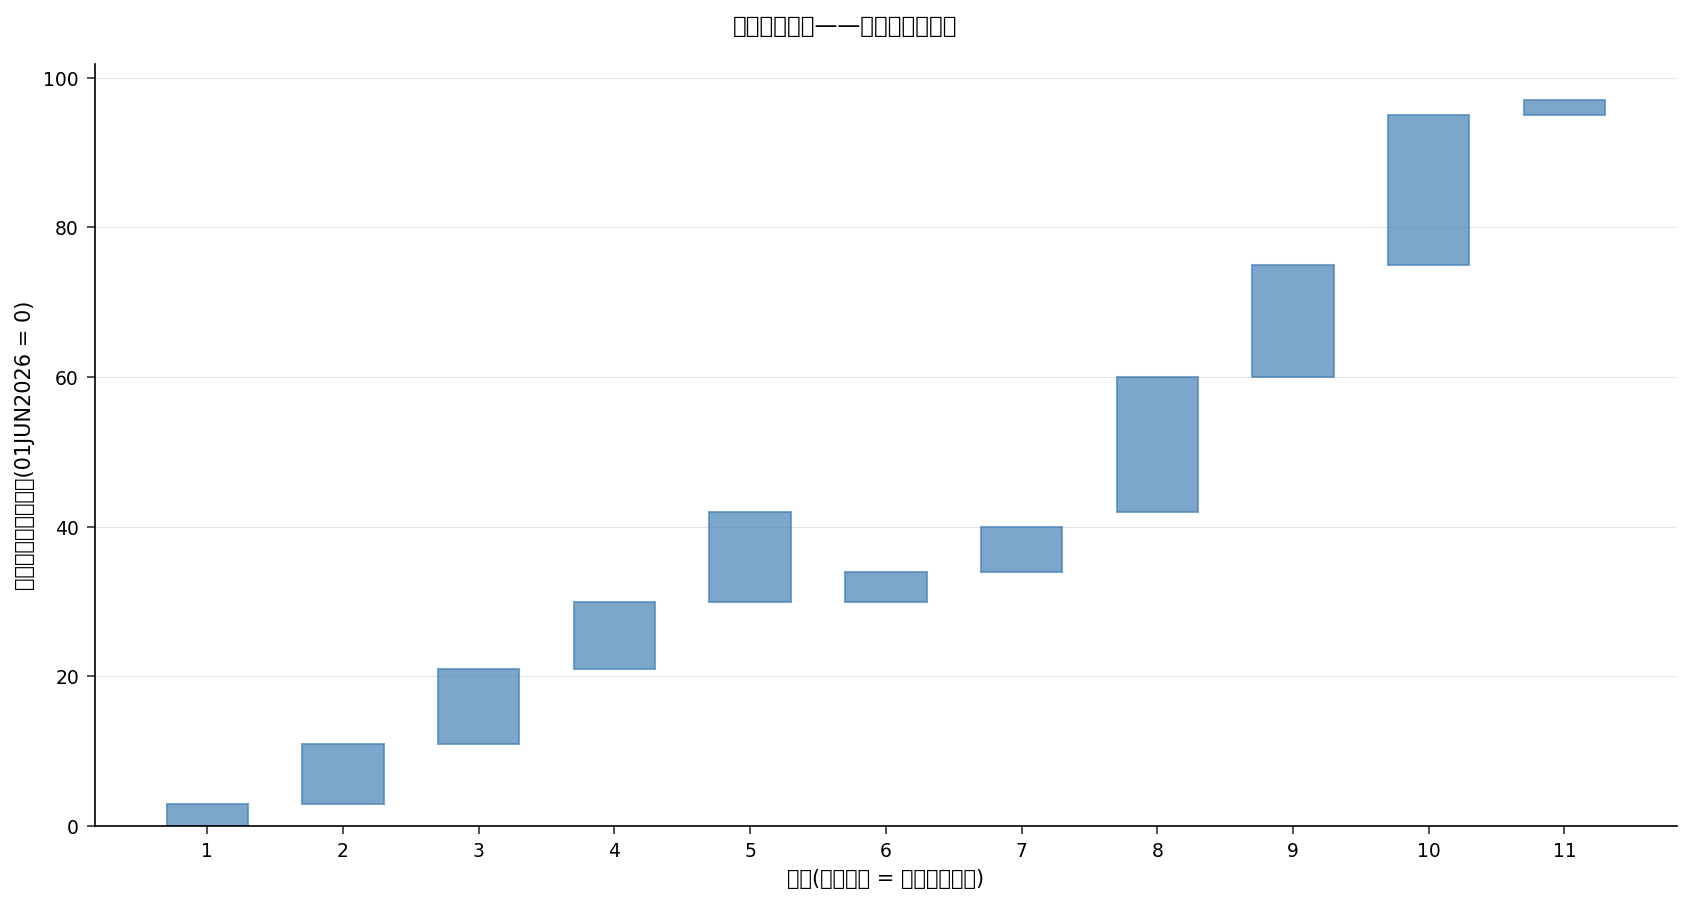

In [8]:
数据 gantt; 设置 sched_es;
   ord = es;          /* 数值型 x = 最早开始顺序 */
运行;
过程 排序 数据=gantt; 按照 ord activity; 运行;
数据 gantt; 设置 gantt; ax = _n_; 运行;   /* 紧凑的 1..11 x 索引 */

ODS GRAPHICS ON / IMAGENAME='gantt' WIDTH=820px HEIGHT=440px;
标题 "车险产品上市——早期进度瀑布图";
过程 SGPLOT 数据=gantt;
   highlow x=ax LOW=es HIGH=ef / type=bar barwidth=0.7;
   XAXIS 标签="任务(从左到右 = 最早开始顺序)"
         integer VALUES=(1 to 11 by 1);
   YAXIS 标签="自项目开始的工作日(01JUN2026 = 0)" grid;
运行;
ODS GRAPHICS OFF;

从左到右阅读，各条沿关键链持续向上攀升。两项打破阶梯的任务——起点低于前一条顶部——是费率提交与批准，即携带时差的活动。

## 各任务的总时差

绘制每项任务的总时差，使关键路径一目了然：每项关键任务都位于零处，只有两项监管任务高于它。

                                                  各任务的总时差(0 = 位于关键路径上)                                                  




NOTE: ODS Graphics is ON (width=820px, height=380px, format=SVG).
NOTE: Option TITLE changed to 各任务的总时差(0 = 位于关键路径上).
NOTE: PROC SGPLOT data=sched_es

NOTE: PROC SGPLOT output written to: ./ods_output/float.svg
NOTE: ODS Graphics is OFF.


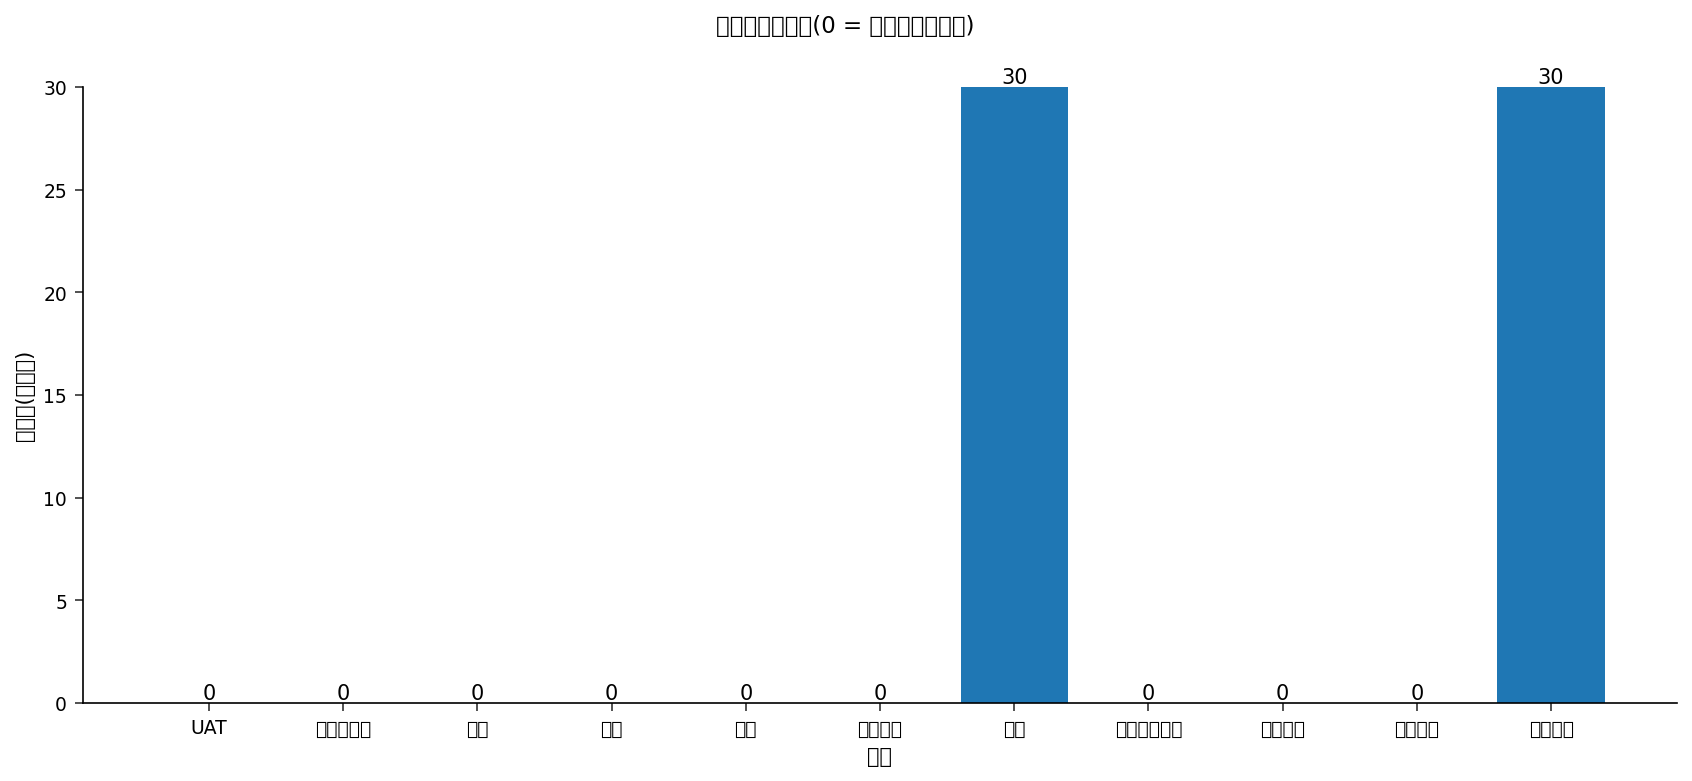

In [9]:
ODS GRAPHICS ON / IMAGENAME='float' WIDTH=820px HEIGHT=380px;
标题 "各任务的总时差(0 = 位于关键路径上)";
过程 SGPLOT 数据=sched_es;
   VBAR activity / RESPONSE=tfloat DATALABEL;
   XAXIS 标签="任务" fitpolicy=rotatethin;
   YAXIS 标签="总时差(工作日)";
运行;
ODS GRAPHICS OFF;

## 早期进度计划下的资源负载

除了时间安排，该计划还争夺两个专业人员池。将每项任务在其占用的工作日上展开，并对每日需求求和，即可得到资源负载曲线——如果每项任务都尽早开始，该计划每天需要多少精算师和开发人员。峰值即该项目在任一时刻所需的最大产能。

                                                     每日资源负载峰值(早期进度)                                                     

                                                  The MEANS Procedure

 Variable    Label            Maximum
 ------------------------------------
 ACTUARIES   精算师                    3
 DEVELOPERS  开发人员                   3
 ------------------------------------

                                                   早期进度下的每日精算师与开发人员负载                                                   




NOTE: DATA load

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Read 10 rows from sched.
NOTE: Wrote load (105 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC MEANS
NOTE: Output dataset rprofile has 90 observations and 3 variables.
NOTE: PROC MEANS statement used.
NOTE: PROC SORT data=rprofile

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 90 rows from rprofile.
NOTE: Wrote rprofile (90 rows, 3 columns).
NOTE: PROC SORT statement used.
NOTE: Option TITLE changed to 每日资源负载峰值(早期进度).
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: ODS Graphics is ON (width=820px, height=360px, format=SVG).
NOTE: Option TITLE changed to 早期进度下的每日精算师与开发人员负载.
NOTE: PROC SGPLOT data=rprofile

NOTE: PROC SGPLOT output written to: ./ods_output/resload.svg
NOTE: ODS Graphics is OFF.


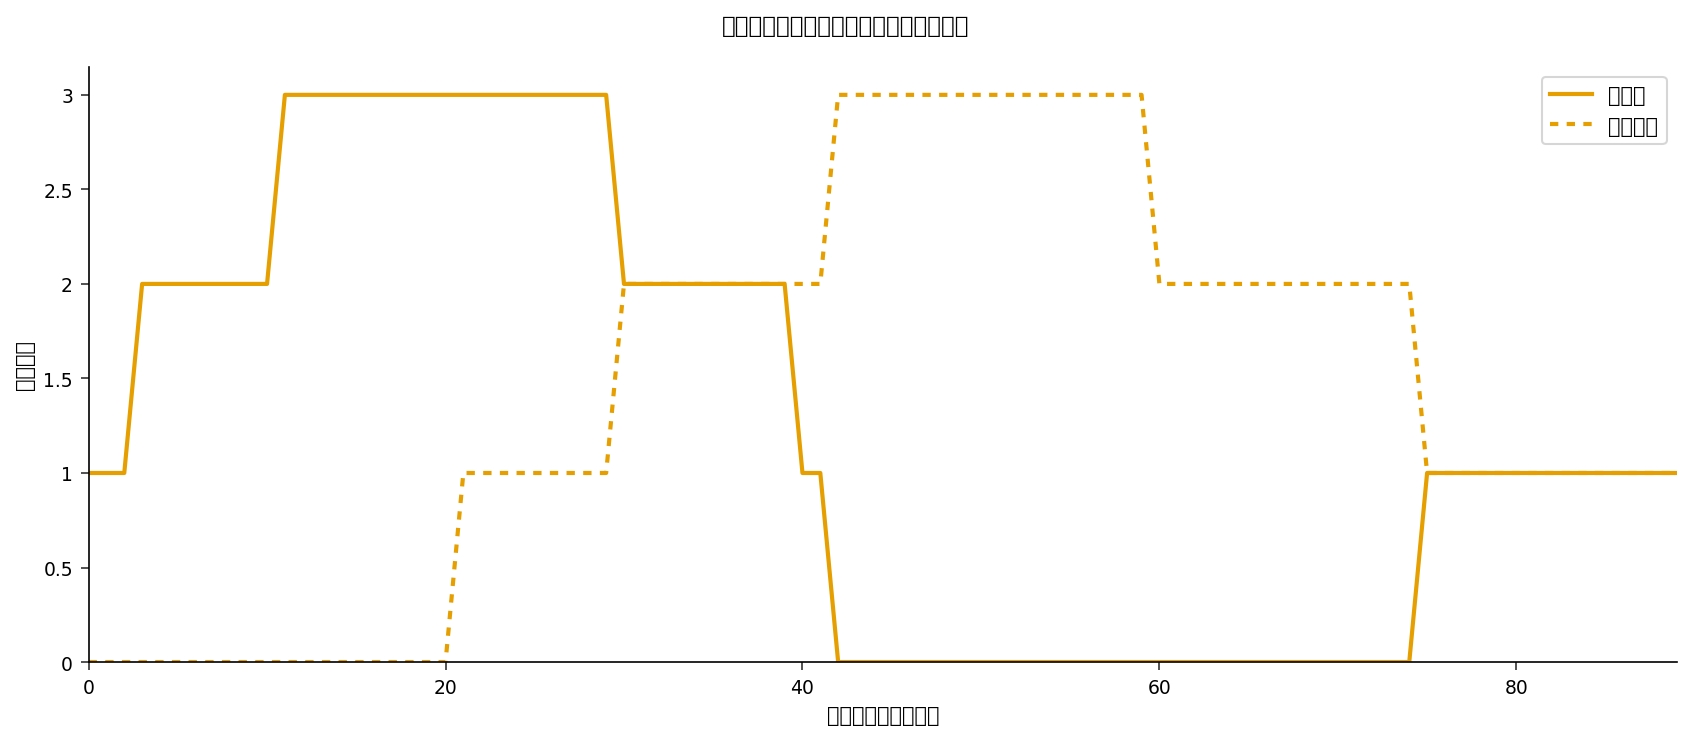

In [10]:
数据 load;
   设置 sched;
   循环 d = es 到 ef-1;
      day = d;
      a_use = actuary;
      d_use = developer;
      输出;
   结束;
   保留 day a_use d_use;
运行;

过程 均值 数据=load NOPRINT NWAY;
   分类 day;
   变量 a_use d_use;
   输出 out=rprofile(drop=_type_ _freq_)
          sum(a_use)=actuaries sum(d_use)=developers;
运行;
过程 排序 数据=rprofile; 按照 day; 运行;

标题 "每日资源负载峰值(早期进度)";
过程 均值 数据=rprofile MAX maxdec=0;
   变量 actuaries developers;
   标签 actuaries="精算师" developers="开发人员";
运行;

ODS GRAPHICS ON / IMAGENAME='resload' WIDTH=820px HEIGHT=360px;
标题 "早期进度下的每日精算师与开发人员负载";
过程 SGPLOT 数据=rprofile;
   SERIES x=day y=actuaries  /
          LINEATTRS=(thickness=2) legendlabel="精算师";
   SERIES x=day y=developers /
          LINEATTRS=(thickness=2 pattern=shortdash)
          legendlabel="开发人员";
   XAXIS 标签="自项目开始的工作日";
   YAXIS 标签="所需人数" MIN=0;
   keylegend / location=inside position=topright;
运行;
ODS GRAPHICS OFF;

## 结果解读

- **发布日期由构建轨道决定，而非监管轨道。** 关键路径为 启动 -> 市场调研 -> 损失数据汇总 -> 定价 -> 系统设计 -> 系统构建 -> UAT -> 代理人培训 -> 发布，makespan 为 97 个工作日（于 13OCT2026 完成）。这些任务中的每一项时差都为零，因此其上的任何延误都会逐日推迟发布。

- **监管分支有一个月的余量。** 费率提交与批准各自携带 30 个工作日的总时差。定价完成后，它们可以晚至各自的最晚开始日期才开始，仍能按时在代理人培训处重新汇合，因为并行的系统构建分支（系统设计 -> 系统构建 -> UAT）是通往发布的两条路径中较长的一条。用规划术语来说，此处提交*并非*约束瓶颈——保单系统构建才是。

- **专业人员需求在不同阶段达到峰值。** 负载曲线显示精算师需求较早达到峰值（贯穿定价），开发人员需求较晚达到峰值（贯穿系统构建），各自峰值为每天三人。由于两个峰值落在不同阶段，一支精简的、按顺序工作的专业团队即可为该计划配备人手——该项目无需同时拥有其精算师与开发人员的最大人数。

**业务要点。** CPM 将一份发布任务清单转化为可执行的进度计划：它识别出保险公司为达成 13OCT2026 必须保护的构建轨道活动，量化监管提交上可用的一个月余量，并表明错开的精算师与开发人员峰值使一支精简的专业团队能够交付该计划。

*实现说明：* SAS 使用 PROC CPM（SAS/OR）进行此计算。Jenner 通过 PROC OPTMODEL 求解支撑该方法的两个最长路径线性规划，得到相同的正向/反向关键路径结果。